In [3]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import pearsonr, ttest_ind
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
try:
    df = pd.read_csv("Fifa 23 Players Data.csv")
    print("Dataset loaded successfully")
except FileNotFoundError:
    print("Error: Dataset file not found")
except Exception as e:
    print("An error occurred:", e)


Dataset loaded successfully


In [5]:
# Standardize expected column names for this dataset
if 'Full Name' in df.columns:
    df['Name'] = df['Full Name']
elif 'Known As' in df.columns:
    df['Name'] = df['Known As']

if 'Club Name' in df.columns:
    df['Club'] = df['Club Name']
# =========================
# NUMPY OPERATIONS
# =========================

# Convert Overall ratings into NumPy array
overall_array = np.array(df['Overall'])

print("NumPy Array Example:")
print(overall_array[:10])

# Statistical computations
print("Mean Overall:", np.mean(overall_array))
print("Standard Deviation:", np.std(overall_array))
print("Maximum Overall:", np.max(overall_array))
print("Minimum Overall:", np.min(overall_array))

# Reshaping example
reshaped = overall_array[:12].reshape(3,4)

print("Reshaped Array:")
print(reshaped)

# Boolean indexing
elite_players = overall_array[overall_array >= 85]

print("Elite Player Ratings:")
print(elite_players[:10])

if 'Value(in Euro)' in df.columns:
    df.rename(columns={'Value(in Euro)': 'Value'}, inplace=True)

if 'Wage(in Euro)' in df.columns:
    df.rename(columns={'Wage(in Euro)': 'Wage'}, inplace=True)


NumPy Array Example:
[91 91 91 91 91 90 90 90 90 90]
Mean Overall: 65.85204164194401
Standard Deviation: 6.788169596105948
Maximum Overall: 91
Minimum Overall: 47
Reshaped Array:
[[91 91 91 91]
 [91 90 90 90]
 [90 90 89 89]]
Elite Player Ratings:
[91 91 91 91 91 90 90 90 90 90]


In [6]:
# Preview data
print(df.head())

         Known As           Full Name  Overall  Potential      Value  \
0        L. Messi        Lionel Messi       91         91   54000000   
1      K. Benzema       Karim Benzema       91         91   64000000   
2  R. Lewandowski  Robert Lewandowski       91         91   84000000   
3    K. De Bruyne     Kevin De Bruyne       91         91  107500000   
4       K. Mbappé       Kylian Mbappé       91         95  190500000   

  Positions Played Best Position Nationality  \
0               RW           CAM   Argentina   
1            CF,ST            CF      France   
2               ST            ST      Poland   
3           CM,CAM            CM     Belgium   
4            ST,LW            ST      France   

                                         Image Link  Age  ...  RM Rating  \
0  https://cdn.sofifa.net/players/158/023/23_60.png   35  ...         91   
1  https://cdn.sofifa.net/players/165/153/23_60.png   34  ...         89   
2  https://cdn.sofifa.net/players/188/545/23_60.pn

In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18539 entries, 0 to 18538
Data columns (total 91 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Known As                     18539 non-null  object
 1   Full Name                    18539 non-null  object
 2   Overall                      18539 non-null  int64 
 3   Potential                    18539 non-null  int64 
 4   Value                        18539 non-null  int64 
 5   Positions Played             18539 non-null  object
 6   Best Position                18539 non-null  object
 7   Nationality                  18539 non-null  object
 8   Image Link                   18539 non-null  object
 9   Age                          18539 non-null  int64 
 10  Height(in cm)                18539 non-null  int64 
 11  Weight(in kg)                18539 non-null  int64 
 12  TotalStats                   18539 non-null  int64 
 13  BaseStats                    18

In [8]:
print(df.describe())
# Timing dataframe summary
%timeit df.describe()

# Timing correlation computation
%timeit df.corr(numeric_only=True)

            Overall     Potential         Value           Age  Height(in cm)  \
count  18539.000000  18539.000000  1.853900e+04  18539.000000   18539.000000   
mean      65.852042     71.016668  2.875461e+06     25.240412     181.550839   
std        6.788353      6.192866  7.635129e+06      4.718163       6.858097   
min       47.000000     48.000000  0.000000e+00     16.000000     155.000000   
25%       62.000000     67.000000  4.750000e+05     21.000000     177.000000   
50%       66.000000     71.000000  1.000000e+06     25.000000     182.000000   
75%       70.000000     75.000000  2.000000e+06     29.000000     186.000000   
max       91.000000     95.000000  1.905000e+08     44.000000     206.000000   

       Weight(in kg)    TotalStats     BaseStats           Wage  \
count   18539.000000  18539.000000  18539.000000   18539.000000   
mean       75.173904   1602.114569    357.946221    8824.537462   
std         7.013593    273.160237     39.628259   19460.531154   
min        

In [9]:
df = df.drop(columns=['Photo', 'Flag', 'Club Logo', 'Real Face'], errors='ignore')

In [10]:
def to_numeric_value(value):
    if isinstance(value, str):
        cleaned = value.replace('€', '').replace('M', 'e6').replace('K', 'e3')
        try:
            return float(cleaned)
        except ValueError:
            return pd.NA
    return pd.to_numeric(value, errors='coerce')


In [11]:
if 'Value' in df.columns:
    df['Value'] = df['Value'].apply(to_numeric_value)

if 'Wage' in df.columns:
    df['Wage'] = df['Wage'].apply(to_numeric_value)

# Drop rows missing required columns or values
required_columns = ['Name', 'Club', 'Age', 'Overall', 'Potential', 'Value', 'Wage', 'Finishing', 'Positioning', 'Shot Power']
missing_required = [col for col in required_columns if col not in df.columns]
if missing_required:
    raise KeyError(f"Missing required columns: {missing_required}")
# Remove duplicate rows
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)

df.drop_duplicates(inplace=True)

df = df.dropna(subset=required_columns)

df['Attack Score'] = (df['Finishing'] + df['Positioning'] + df['Shot Power']) / 3

df['Efficiency'] = df['Overall'] / df['Potential']

df['Value Efficiency'] = df['Overall'] / df['Value'].replace(0, pd.NA)

Number of duplicate rows: 119


In [12]:
def categorize_player(overall):
    if overall >= 85:
        return "Elite"
    elif overall >= 75:
        return "Good"
    return "Average"


In [13]:
df['Player Level'] = df['Overall'].apply(categorize_player)

In [14]:
# String manipulation examples
df['Name Upper'] = df['Name'].str.upper()

# Remove extra spaces
df['Club'] = df['Club'].str.strip()

# Extract first word from club name
df['Club Prefix'] = df['Club'].str.split().str[0]

print(df[['Name', 'Name Upper', 'Club Prefix']].head())

                 Name          Name Upper Club Prefix
0        Lionel Messi        LIONEL MESSI       Paris
1       Karim Benzema       KARIM BENZEMA        Real
2  Robert Lewandowski  ROBERT LEWANDOWSKI          FC
3     Kevin De Bruyne     KEVIN DE BRUYNE  Manchester
4       Kylian Mbappé       KYLIAN MBAPPÉ       Paris


In [15]:
# Regular expression example
df['Club Clean'] = df['Club'].str.replace(r'[^A-Za-z0-9 ]', '', regex=True)

print(df[['Club', 'Club Clean']].head())

                  Club          Club Clean
0  Paris Saint-Germain  Paris SaintGermain
1       Real Madrid CF      Real Madrid CF
2         FC Barcelona        FC Barcelona
3      Manchester City     Manchester City
4  Paris Saint-Germain  Paris SaintGermain


In [16]:
df_clean = df[[
    'Name',
    'Club',
    'Age',
    'Overall',
    'Potential',
    'Value',
    'Wage',
    'Attack Score',
    'Efficiency',
    'Value Efficiency',
    'Player Level'
]]

In [17]:
print(df_clean.describe())
df_clean.to_csv("cleaned_fifa23_data.csv", index=False)
# Export to JSON
df_clean.to_json("cleaned_fifa23_data.json", orient='records')

print("JSON file exported successfully")



                Age       Overall     Potential         Value           Wage  \
count  18420.000000  18420.000000  18420.000000  1.842000e+04   18420.000000   
mean      25.243920     65.792942     70.963301  2.842697e+06    8733.099891   
std        4.725456      6.770177      6.170634  7.645260e+06   19452.416115   
min       16.000000     47.000000     48.000000  0.000000e+00       0.000000   
25%       21.000000     62.000000     67.000000  4.750000e+05    1000.000000   
50%       25.000000     66.000000     71.000000  9.750000e+05    3000.000000   
75%       29.000000     70.000000     75.000000  2.000000e+06    7000.000000   
max       44.000000     91.000000     95.000000  1.905000e+08  450000.000000   

       Attack Score    Efficiency  
count  18420.000000  18420.000000  
mean      51.478176      0.928719  
std       16.159528      0.073123  
min       14.666667      0.666667  
25%       39.333333      0.876712  
50%       55.000000      0.946429  
75%       63.666667      1.

In [18]:
# Export to Excel
df_clean.to_excel("cleaned_fifa23_data.xlsx", index=False)

print("Excel file exported successfully")

Excel file exported successfully


In [19]:
cleaned_df = pd.read_csv("cleaned_fifa23_data.csv")
print("First 5 rows of the cleaned dataset:")
display(cleaned_df.head())

First 5 rows of the cleaned dataset:


,Name,Club,Age,Overall,Potential,Value,Wage,Attack Score,Efficiency,Value Efficiency,Player Level
0,Lionel Messi,Paris Saint-Germain,35,91,91,54000000,195000,89.666667,1.000000,1.685185e-06,Elite
1,Karim Benzema,Real Madrid CF,34,91,91,64000000,450000,90.333333,1.000000,1.421875e-06,Elite
2,Robert Lewandowski,FC Barcelona,33,91,91,84000000,420000,93.000000,1.000000,1.083333e-06,Elite
3,Kevin De Bruyne,Manchester City,31,91,91,107500000,350000,88.333333,1.000000,8.465116e-07,Elite
4,Kylian Mbappé,Paris Saint-Germain,23,91,95,190500000,230000,91.000000,0.957895,4.776903e-07,Elite



--- PIVOT TABLE ---
Player Level             Average  Elite       Good
Club                                              
1. FC Heidenheim 1846  66.107143    NaN        NaN
1. FC Kaiserslautern   64.689655    NaN  75.000000
1. FC Köln             66.500000    NaN  76.333333
1. FC Magdeburg        65.066667    NaN        NaN
1. FC Nürnberg         66.214286    NaN        NaN


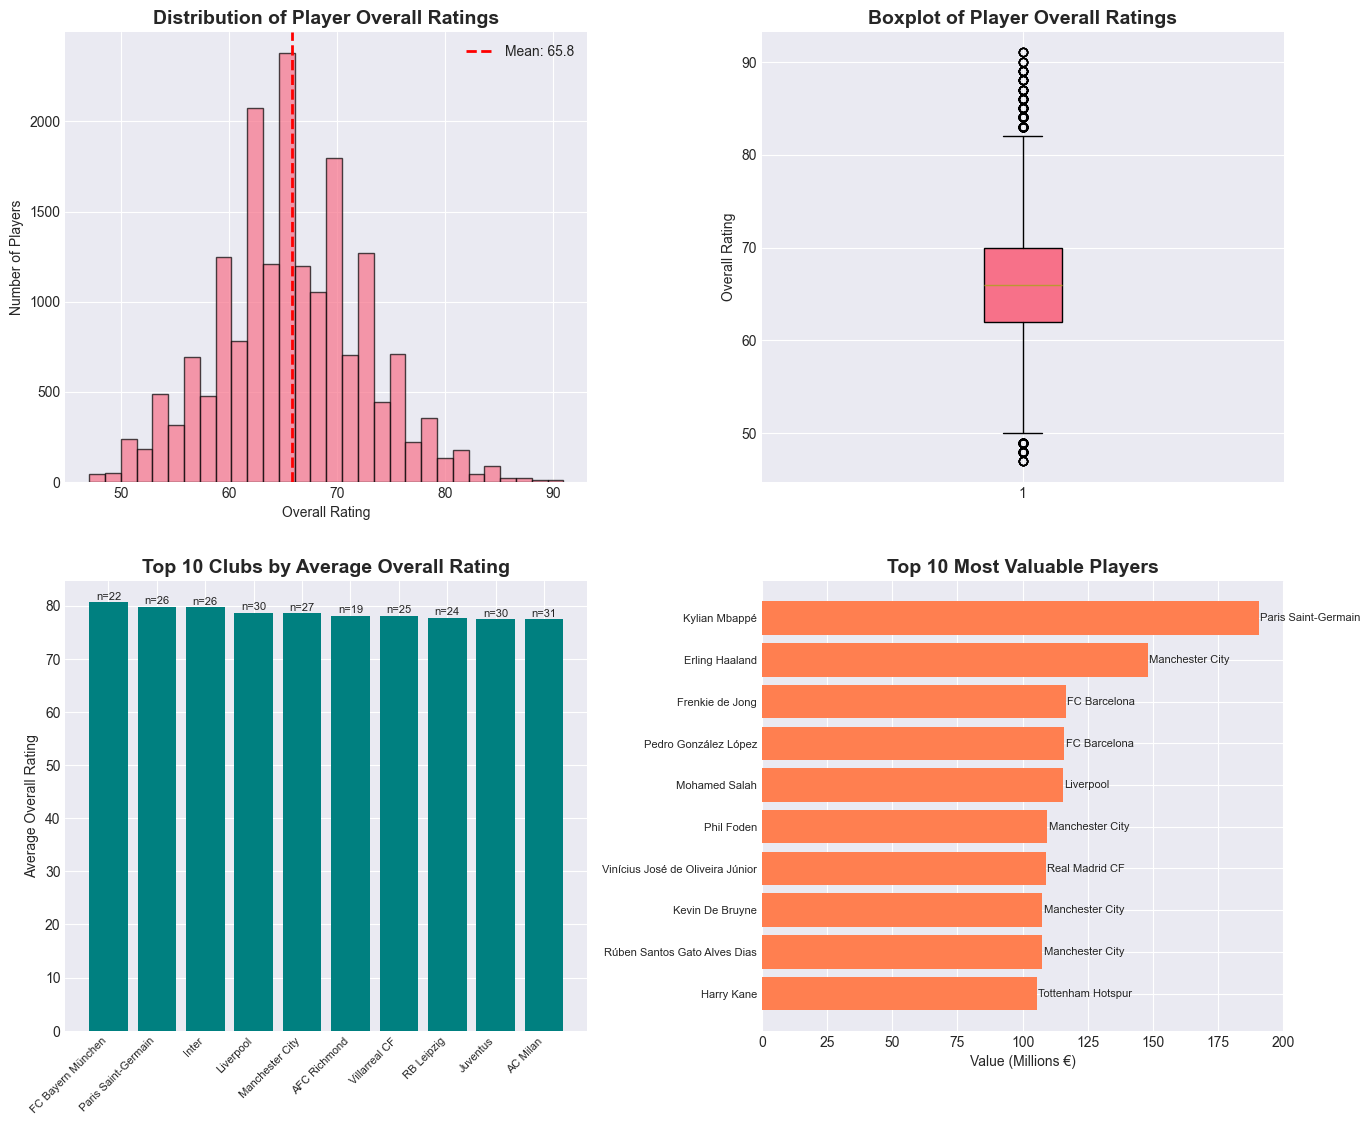

In [20]:
# Set style for better looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Create a figure with multiple subplots
fig = plt.figure(figsize=(20, 16))

# 1. Distribution of Player Overall Ratings
ax1 = fig.add_subplot(3, 3, 1)
df['Overall'].hist(bins=30, edgecolor='black', alpha=0.7)
ax1.set_title('Distribution of Player Overall Ratings', fontsize=14, fontweight='bold')
ax1.set_xlabel('Overall Rating')
ax1.set_ylabel('Number of Players')
ax1.axvline(df['Overall'].mean(), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {df["Overall"].mean():.1f}')
ax1.legend()


# 2. Boxplot of Player Overall Ratings
ax2 = fig.add_subplot(3, 3, 2)

ax2.boxplot(
    df['Overall'],
    patch_artist=True
)

ax2.set_title(
    'Boxplot of Player Overall Ratings',
    fontsize=14,
    fontweight='bold'
)

ax2.set_ylabel('Overall Rating')


# 3. Top 10 Most Valuable Players
ax4 = fig.add_subplot(3, 3, 5)
top_valuable = df.nlargest(10, 'Value')[['Name', 'Value', 'Club']]
bars = ax4.barh(range(len(top_valuable)), top_valuable['Value'].values / 1e6, color='coral')
ax4.set_yticks(range(len(top_valuable)))
ax4.set_yticklabels(top_valuable['Name'].values, fontsize=8)
ax4.set_xlabel('Value (Millions €)')
ax4.set_title('Top 10 Most Valuable Players', fontsize=14, fontweight='bold')
ax4.invert_yaxis()
# Add club names as text
for i, (idx, row) in enumerate(top_valuable.iterrows()):
    ax4.text(row['Value']/1e6 + 0.5, i, row['Club'], va='center', fontsize=8)
    

#4. Top 10 Clubs by Average Overall Rating
ax8 = fig.add_subplot(3, 3, 4)
top_clubs = df.groupby('Club').agg({'Overall': 'mean', 'Name': 'count'}).nlargest(10, 'Overall')
# Pivot Table Example
pivot_table = pd.pivot_table(
    df,
    values='Overall',
    index='Club',
    columns='Player Level',
    aggfunc='mean'
)

print("\n--- PIVOT TABLE ---")
print(pivot_table.head())
bars = ax8.bar(range(len(top_clubs)), top_clubs['Overall'].values, color='teal')
ax8.set_xticks(range(len(top_clubs)))
ax8.set_xticklabels(top_clubs.index, rotation=45, ha='right', fontsize=8)
ax8.set_ylabel('Average Overall Rating')
ax8.set_title('Top 10 Clubs by Average Overall Rating', fontsize=14, fontweight='bold')
# Add player count as text
for i, (idx, row) in enumerate(top_clubs.iterrows()):
    ax8.text(i, row['Overall'] + 0.5, f'n={int(row["Name"])}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()




--- CORRELATION MATRIX ---
                       Age   Overall  Potential     Value      Wage  \
Age               1.000000  0.446743  -0.262745  0.032708  0.146047   
Overall           0.446743  1.000000   0.657323  0.560209  0.598478   
Potential        -0.262745  0.657323   1.000000  0.530459  0.495757   
Value             0.032708  0.560209   0.530459  1.000000  0.823167   
Wage              0.146047  0.598478   0.495757  0.823167  1.000000   
Attack Score      0.144228  0.422255   0.271968  0.256554  0.275503   
Efficiency        0.868297  0.564344  -0.248296  0.122433  0.206335   
Value Efficiency  0.134262 -0.519750  -0.567978 -0.204298 -0.217489   

                  Attack Score  Efficiency  Value Efficiency  
Age                   0.144228    0.868297          0.134262  
Overall               0.422255    0.564344         -0.519750  
Potential             0.271968   -0.248296         -0.567978  
Value                 0.256554    0.122433         -0.204298  
Wage             

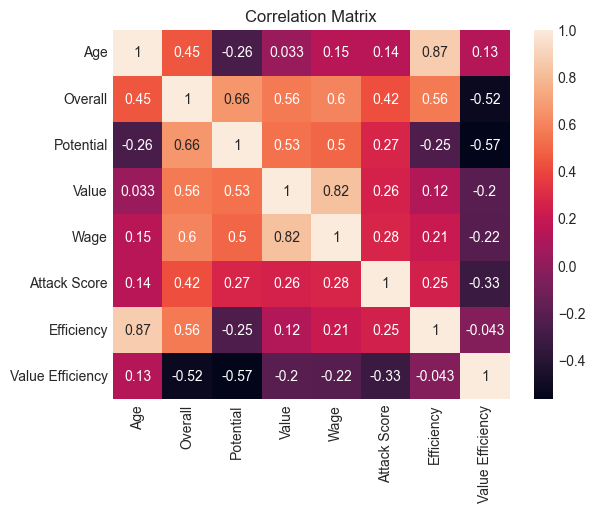

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation matrix
corr_matrix = cleaned_df.corr(numeric_only=True)

print("\n--- CORRELATION MATRIX ---")
print(corr_matrix)

# Heatmap
plt.figure()
sns.heatmap(corr_matrix, annot=True)
plt.title("Correlation Matrix")
plt.show()

In [35]:
from scipy.stats import ttest_ind

elite = cleaned_df[cleaned_df['Player Level'] == 'Elite']['Attack Score']
average = cleaned_df[cleaned_df['Player Level'] == 'Average']['Attack Score']

# Perform t-test
t_stat, p_value = ttest_ind(elite, average)

print("\n--- T-TEST RESULT ---")
print("T-Statistic:", t_stat)
print("P-Value:", p_value)


--- T-TEST RESULT ---
T-Statistic: 11.441937028735635
P-Value: 3.3428185734625614e-30


In [23]:
if p_value < 0.05:
    print("Reject Null Hypothesis: Significant difference exists")
else:
    print("Fail to Reject Null Hypothesis")

Reject Null Hypothesis: Significant difference exists


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X = cleaned_df[['Value']]
y = cleaned_df['Overall']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- MODEL PERFORMANCE ---")
print("Mean Squared Error:", mse)
print("R2 Score:", r2)


--- MODEL PERFORMANCE ---
Mean Squared Error: 31.85395924356081
R2 Score: 0.31230056829407915


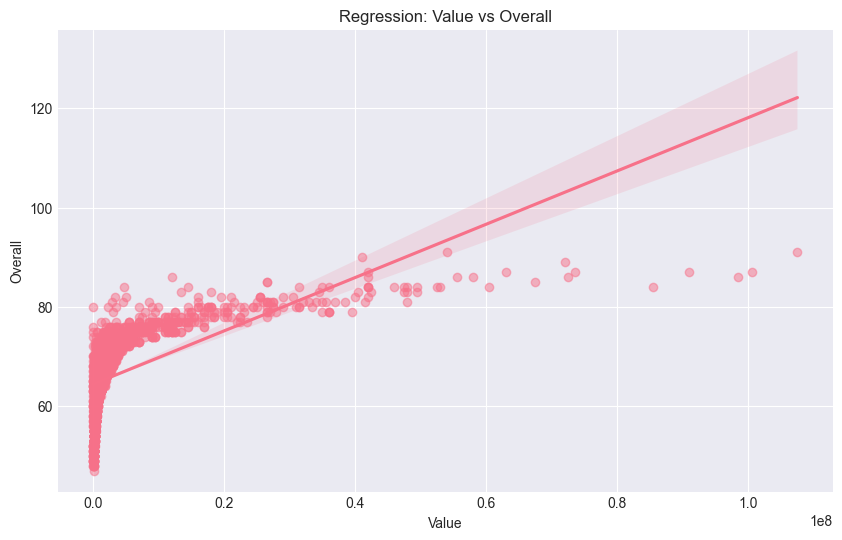

In [32]:
plt.figure(figsize=(10,6))

sns.regplot(
    x=X_test['Value'],
    y=y_test,
    scatter_kws={'alpha':0.5}
)

plt.xlabel("Value")
plt.ylabel("Overall")
plt.title("Regression: Value vs Overall")

plt.show()

In [33]:
from scipy.stats import pearsonr

corr, p_val = pearsonr(cleaned_df['Value'], cleaned_df['Overall'])

print("\n--- PEARSON TEST ---")
print("Correlation:", corr)
print("P-value:", p_val)
if corr > 0:
    print("Positive correlation exists")
else:
    print("Negative correlation exists")

if p_val < 0.05:
    print("Correlation is statistically significant")
else:
    print("Correlation is NOT statistically significant")


--- PEARSON TEST ---
Correlation: 0.5602089513916008
P-value: 0.0
Positive correlation exists
Correlation is statistically significant


In [27]:
import pandas as pd
cleaned_df = pd.read_csv("Cleaned_fifa23_data.csv")
print("First 5 rows of the cleaned dataset:")
display(cleaned_df.head())
     

First 5 rows of the cleaned dataset:


,Name,Club,Age,Overall,Potential,Value,Wage,Attack Score,Efficiency,Value Efficiency,Player Level
0,Lionel Messi,Paris Saint-Germain,35,91,91,54000000,195000,89.666667,1.000000,1.685185e-06,Elite
1,Karim Benzema,Real Madrid CF,34,91,91,64000000,450000,90.333333,1.000000,1.421875e-06,Elite
2,Robert Lewandowski,FC Barcelona,33,91,91,84000000,420000,93.000000,1.000000,1.083333e-06,Elite
3,Kevin De Bruyne,Manchester City,31,91,91,107500000,350000,88.333333,1.000000,8.465116e-07,Elite
4,Kylian Mbappé,Paris Saint-Germain,23,91,95,190500000,230000,91.000000,0.957895,4.776903e-07,Elite


In [37]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Define features (X) and target (y)
X = cleaned_df[['Age', 'Potential', 'Value', 'Wage', 'Attack Score', 'Efficiency']]
y = cleaned_df['Overall']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- MODEL PERFORMANCE ---")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R2 Score: {r2:.2f}")

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("\n--- CROSS VALIDATION ---")
print("Cross Validation Scores:", cv_scores)
print("Average CV Score:", cv_scores.mean())
     


--- MODEL PERFORMANCE ---
Mean Squared Error: 0.15
R2 Score: 1.00

--- CROSS VALIDATION ---
Cross Validation Scores: [0.60019472 0.96339907 0.89486938 0.84257256 0.90983258]
Average CV Score: 0.8421736625234093


In [29]:
# Create prediction column
cleaned_df['Predicted Overall'] = model.predict(
    cleaned_df[['Age', 'Potential', 'Value', 'Wage', 'Attack Score', 'Efficiency']]
)

In [30]:
print(cleaned_df[['Name', 'Overall', 'Predicted Overall']].head())

                 Name  Overall  Predicted Overall
0        Lionel Messi       91          90.741274
1       Karim Benzema       91          92.901926
2  Robert Lewandowski       91          92.732440
3     Kevin De Bruyne       91          92.272743
4       Kylian Mbappé       91          92.319988


In [38]:
cleaned_df.to_csv("advanced_fifa_data.csv", index=False)
     


--- PCA RESULTS ---
         PC1       PC2
0  11.931646 -0.676378
1  20.181236 -1.808276
2  20.785702 -2.196664
3  20.275439 -2.695207
4  22.739663 -5.510896


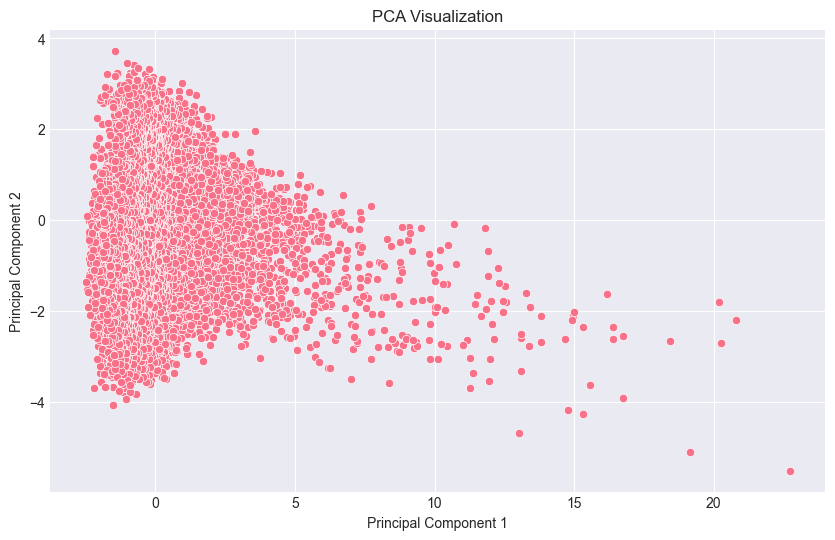

In [39]:
# =========================================
# PCA DIMENSIONALITY REDUCTION
# =========================================

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Select numerical features
features = cleaned_df[
    ['Age', 'Potential', 'Value', 'Wage', 'Attack Score', 'Efficiency']
]

# Standardize features
scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

# Apply PCA
pca = PCA(n_components=2)

principal_components = pca.fit_transform(scaled_features)

# Create PCA DataFrame
pca_df = pd.DataFrame(
    data=principal_components,
    columns=['PC1', 'PC2']
)

print("\n--- PCA RESULTS ---")
print(pca_df.head())

# PCA Visualization
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='PC1',
    y='PC2',
    data=pca_df
)

plt.title('PCA Visualization')

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.show()

                 Name  Cluster
0        Lionel Messi        2
1       Karim Benzema        2
2  Robert Lewandowski        2
3     Kevin De Bruyne        2
4       Kylian Mbappé        2


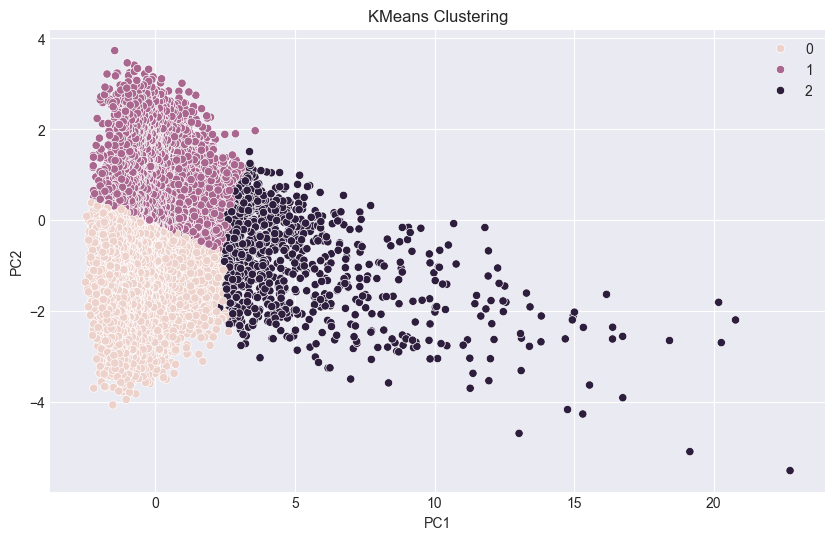

In [40]:
from sklearn.cluster import KMeans

# KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(scaled_features)

cleaned_df['Cluster'] = clusters

print(cleaned_df[['Name', 'Cluster']].head())

# Cluster visualization
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=pca_df['PC1'],
    y=pca_df['PC2'],
    hue=clusters
)

plt.title('KMeans Clustering')
plt.show()

In [41]:
print("\n==============================")
print("FINAL PROJECT SUMMARY")
print("==============================")

print("""
1. Dataset cleaned successfully
2. Missing values handled
3. Duplicate records removed
4. New features engineered
5. Statistical analysis completed
6. Correlation analysis performed
7. T-test conducted
8. Linear Regression model trained
9. PCA dimensionality reduction completed
10. KMeans clustering performed
11. Dataset exported to CSV, JSON, and Excel
12. Visualizations generated successfully
""")


FINAL PROJECT SUMMARY

1. Dataset cleaned successfully
2. Missing values handled
3. Duplicate records removed
4. New features engineered
5. Statistical analysis completed
6. Correlation analysis performed
7. T-test conducted
8. Linear Regression model trained
9. PCA dimensionality reduction completed
10. KMeans clustering performed
11. Dataset exported to CSV, JSON, and Excel
12. Visualizations generated successfully

